In [4]:
from sklearn.datasets import load_breast_cancer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score
X, y = load_breast_cancer(return_X_y=True)
clf = LogisticRegression(solver="newton-cholesky", random_state=0).fit(X, y)
# Prediksi probabilitas kelas 1 (benign)
y_prob = clf.predict_proba(X)[:, 1]

In [19]:
print(f'{roc_auc_score(y, clf.predict_proba(X)[:, 1]):.4f}')
print(f'{roc_auc_score(y, clf.decision_function(X)):.4f}')


0.9947
0.9947


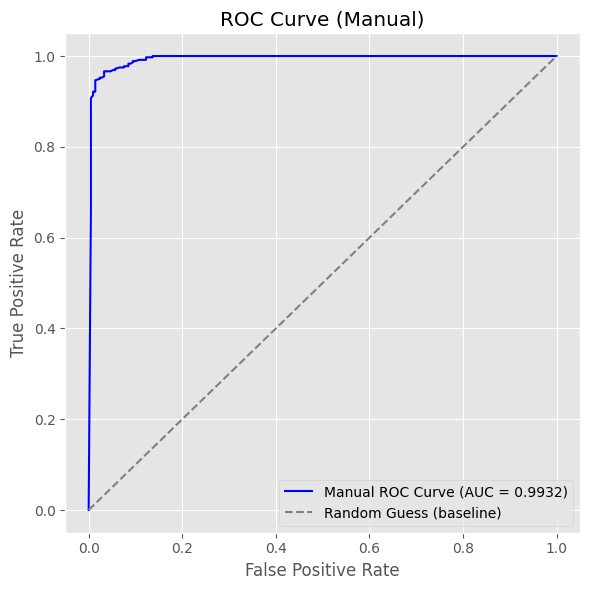

In [ ]:
import matplotlib.pyplot as plt
from sklearn.datasets import load_breast_cancer
from sklearn.linear_model import LogisticRegression

# === STEP 1: Load Data & Train Model ===
X, y = load_breast_cancer(return_X_y=True)
clf = LogisticRegression(solver="newton-cholesky", random_state=0).fit(X, y)
y_prob = clf.predict_proba(X)[:, 1]  # probabilitas kelas 1

# === STEP 2: Manual ROC AUC Function ===
def manual_roc_auc(y_true, y_prob, num_thresholds=100):
    thresholds = [i / num_thresholds for i in range(num_thresholds + 1)]
    roc_points = []

    for thresh in thresholds:
        y_pred = [1 if p >= thresh else 0 for p in y_prob]

        TP = sum(1 for yt, yp in zip(y_true, y_pred) if yt == 1 and yp == 1)
        TN = sum(1 for yt, yp in zip(y_true, y_pred) if yt == 0 and yp == 0)
        FP = sum(1 for yt, yp in zip(y_true, y_pred) if yt == 0 and yp == 1)
        FN = sum(1 for yt, yp in zip(y_true, y_pred) if yt == 1 and yp == 0)

        TPR = TP / (TP + FN) if (TP + FN) > 0 else 0
        FPR = FP / (FP + TN) if (FP + TN) > 0 else 0

        roc_points.append((FPR, TPR))

    # Urutkan berdasarkan FPR
    roc_points.sort()

    # Hitung AUC (trapezoid)
    auc = 0.0
    for i in range(1, len(roc_points)):
        x1, y1 = roc_points[i - 1]
        x2, y2 = roc_points[i]
        auc += (x2 - x1) * (y1 + y2) / 2

    return auc, roc_points

# === STEP 3: Hitung AUC dan Simpan Titik ROC ===
auc, roc_points = manual_roc_auc(y, y_prob)

# === STEP 4: Plot ROC Curve ===
fpr_list, tpr_list = zip(*roc_points)

plt.figure(figsize=(6, 6))
plt.plot(fpr_list, tpr_list, color='blue', label=f"Manual ROC Curve (AUC = {auc:.4f})")
plt.plot([0, 1], [0, 1], color='gray', linestyle='--', label='Random Guess (baseline)')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve (Manual)")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


C:\Users\71486\AppData\Local\Temp\ipykernel_43152\1361544129.py:33: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  auc = -1 * np.trapz(TPR, FPR)


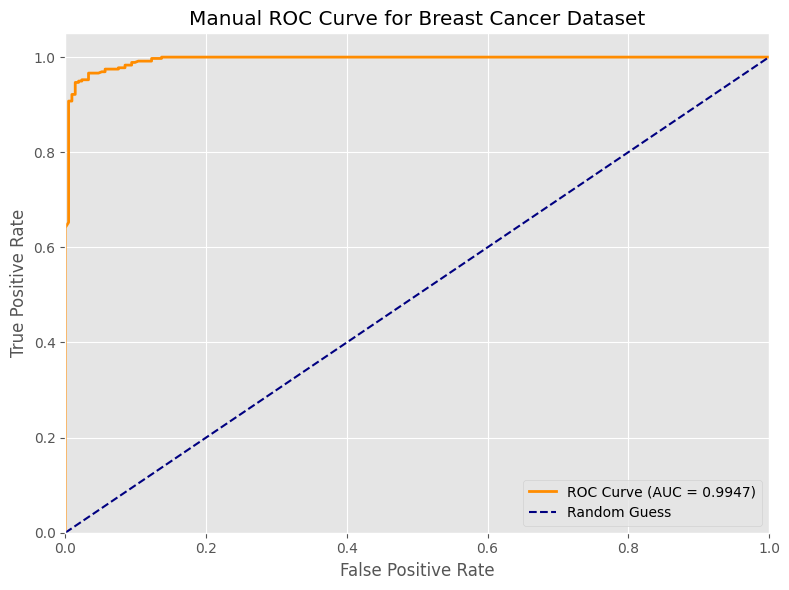

In [14]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import load_breast_cancer
from sklearn.linear_model import LogisticRegression

# Load dataset dan fit model
X, y = load_breast_cancer(return_X_y=True)
clf = LogisticRegression(solver="newton-cholesky", random_state=0).fit(X, y)
y_prob = clf.predict_proba(X)[:, 1]

# Hitung jumlah positif dan negatif
P = sum(y)
N = len(y) - P

# Thresholds
thresholds = np.arange(0.0, 1.01, 0.001)
TPR = []
FPR = []

# Iterasi semua threshold
for thresh in thresholds:
    TP = FP = 0
    for i in range(len(y_prob)):
        if y_prob[i] >= thresh:
            if y[i] == 1:
                TP += 1
            else:
                FP += 1
    TPR.append(TP / P)
    FPR.append(FP / N)

# Hitung AUC dengan trapezoidal rule
auc = -1 * np.trapz(TPR, FPR)

# Plot ROC Curve
plt.figure(figsize=(8, 6))
plt.plot(FPR, TPR, linestyle='-', marker=None, color='darkorange', lw=2, label=f'ROC Curve (AUC = {auc:.4f})')
plt.plot([0, 1], [0, 1], color='navy', linestyle='--', label='Random Guess')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Manual ROC Curve for Breast Cancer Dataset')
plt.legend(loc="lower right")
plt.grid(True)
plt.tight_layout()
plt.show()


C:\Users\71486\AppData\Local\Temp\ipykernel_43152\1276183818.py:35: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  auc = np.trapz(tpr_list, fpr_list)


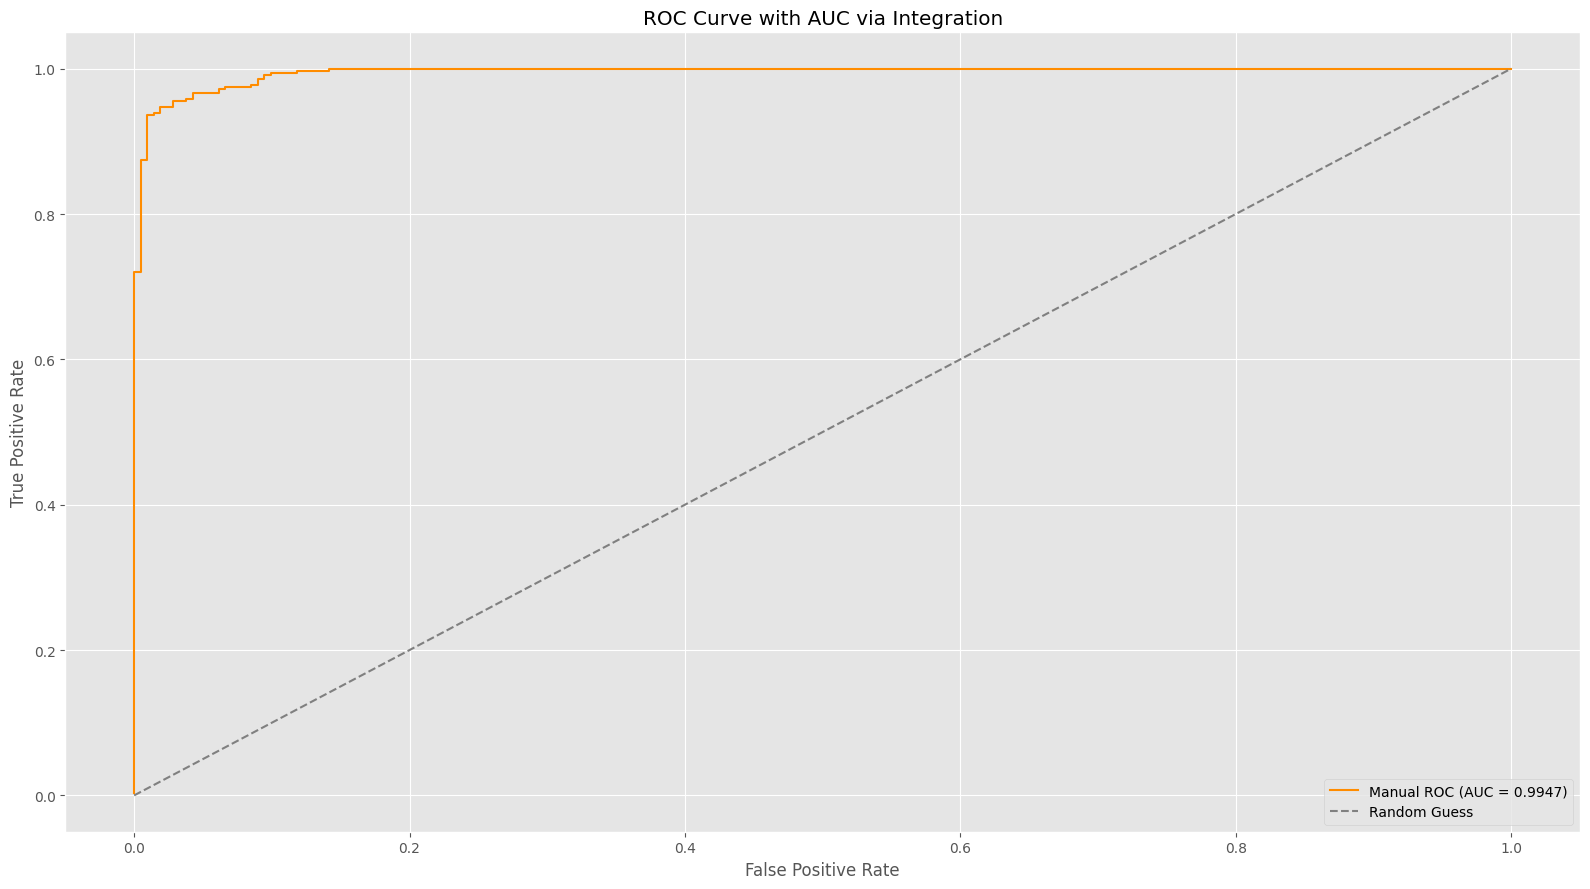

In [ ]:
    import numpy as np
    import matplotlib.pyplot as plt
    from sklearn.datasets import load_breast_cancer
    from sklearn.linear_model import LogisticRegression

    # Step 1: Load & train
    X, y = load_breast_cancer(return_X_y=True)
    clf = LogisticRegression(solver='liblinear').fit(X, y)
    y_prob = clf.predict_proba(X)[:, 1]

    # Step 2: Sort by predicted probabilities (descending)
    sorted_indices = np.argsort(-y_prob)
    y = y[sorted_indices]
    y_prob = y_prob[sorted_indices]

    # Step 3: Create thresholds at each unique predicted probability
    thresholds = np.unique(y_prob)[::-1]  # dari besar ke kecil
    tpr_list = []
    fpr_list = []

    P = np.sum(y == 1)
    N = np.sum(y == 0)

    # Step 4: For each threshold, compute TPR and FPR
    for thresh in thresholds:
        y_pred = (y_prob >= thresh).astype(int)
        TP = np.sum((y_pred == 1) & (y == 1))
        FP = np.sum((y_pred == 1) & (y == 0))
        TPR = TP / P
        FPR = FP / N
        tpr_list.append(TPR)
        fpr_list.append(FPR)

    # Step 5: Integrate TPR over FPR (trapezoidal rule = numerical integral)
    auc = np.trapz(tpr_list, fpr_list)

    # Step 6: Plot ROC
    plt.plot(fpr_list, tpr_list, label=f"Manual ROC (AUC = {auc:.4f})", color='darkorange')
    plt.plot([0, 1], [0, 1], '--', color='gray', label="Random Guess")
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.title("ROC Curve with AUC via Integration")
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()


In [28]:
np.trapz(tpr_list, fpr_list)


C:\Users\71486\AppData\Local\Temp\ipykernel_43152\1733144996.py:1: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  np.trapz(tpr_list, fpr_list)


np.float64(0.9947412927435126)

In [30]:
np.sqrt(-1)

C:\Users\71486\AppData\Local\Temp\ipykernel_43152\3438155168.py:1: RuntimeWarning: invalid value encountered in sqrt
  np.sqrt(-1)


np.float64(nan)